# 03 — Exploratory Data Analysis (EDA)
**Bluestock Capstone I: Mutual Fund Analytics**

---
## Imports & Setup

In [32]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

BASE_DIR = Path().resolve().parent
PROC     = BASE_DIR / 'data' / 'processed'
CHARTS   = BASE_DIR / 'reports' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

print('Setup complete.')
print('Charts directory:', CHARTS)

Setup complete.
Charts directory: /home/l011yp0p/data/intership/bluestock_mf_capstone/reports/charts


---
## Load Datasets

In [33]:
nav        = pd.read_csv(PROC / 'clean_nav_history.csv',         parse_dates=['date'])
aum        = pd.read_csv(PROC / 'clean_aum_by_fund_house.csv')
sip        = pd.read_csv(PROC / 'clean_monthly_sip_inflows.csv', parse_dates=['month'])
cat_inflow = pd.read_csv(PROC / 'clean_category_inflows.csv')
tx         = pd.read_csv(PROC / 'clean_investor_transactions.csv', parse_dates=['transaction_date'])
folio      = pd.read_csv(PROC / 'clean_industry_folio_count.csv', parse_dates=['month'])
holdings   = pd.read_csv(PROC / 'clean_portfolio_holdings.csv')
perf       = pd.read_csv(PROC / 'clean_scheme_performance.csv')
fm         = pd.read_csv(PROC / 'clean_fund_master.csv')
bench      = pd.read_csv(PROC / 'clean_benchmark_indicies.csv') 

print('Datasets loaded:')
for name, df in [('clean_nav_history',nav),('clean_aum_by_fund_house',aum),
                  ('clean_monthly_sip_inflows',sip),('clean_category_inflows',cat_inflow),
                  ('clean_investor_transactions',tx),('clean_industry_folio_count',folio),
                  ('clean_portfolio_holdings',holdings),('clean_performance',perf),
                  ('clean_fund_master',fm)]:
    print(f'  {name:<35}  {df.shape}')

Datasets loaded:
  clean_nav_history                    (46000, 4)
  clean_aum_by_fund_house              (90, 5)
  clean_monthly_sip_inflows            (36, 6)
  clean_category_inflows               (144, 3)
  clean_investor_transactions          (13048, 13)
  clean_industry_folio_count           (21, 6)
  clean_portfolio_holdings             (322, 8)
  clean_performance                    (40, 20)
  clean_fund_master                    (40, 15)


---
## 1. NAV Trend Analysis

**Objective:** Plot daily NAV for all schemes 2019–2025.
Highlighting the COVID recovery, **2023 Rally** and **2024 Market Correction**.


In [34]:
import plotly.express as px

top6 = (nav.groupby("amfi_code")["nav"].mean().nlargest(6).index)
df = nav[nav["amfi_code"].isin(top6)]
fig = px.line(df,x="date",y="nav",color="amfi_code",title="NAV Trend Analysis (Top 6 Schemes)")
fig.add_vrect(x0="2023-01-01",x1="2023-12-31",annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-01-01",x1="2024-06-30",annotation_text="2024 Correction")
fig.show()

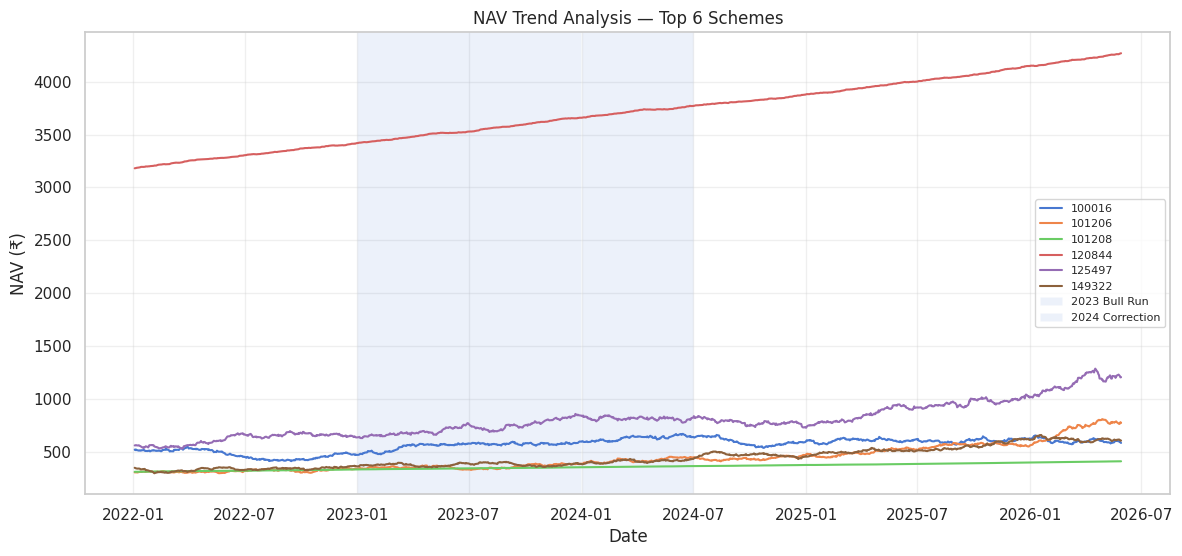

In [35]:
fig, ax = plt.subplots(figsize=(14,6))

top6 = nav.groupby("amfi_code")["nav"].mean().nlargest(6).index
df_top6 = nav[nav["amfi_code"].isin(top6)]

for code, grp in df_top6.groupby("amfi_code"):
    ax.plot(grp["date"], grp["nav"], label=code)

ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"), alpha=0.1, label="2023 Bull Run")
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-06-30"), alpha=0.1, label="2024 Correction")
ax.set(title="NAV Trend Analysis — Top 6 Schemes", xlabel="Date", ylabel="NAV (₹)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.savefig(CHARTS/"nav_trend_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 2. AUM Growth Analysis

**Objective:** Grouped bar chart of AUM by fund house (2022–2025).
Highlight **SBI dominance at ₹12.5 Lakh Crore** in 2025.


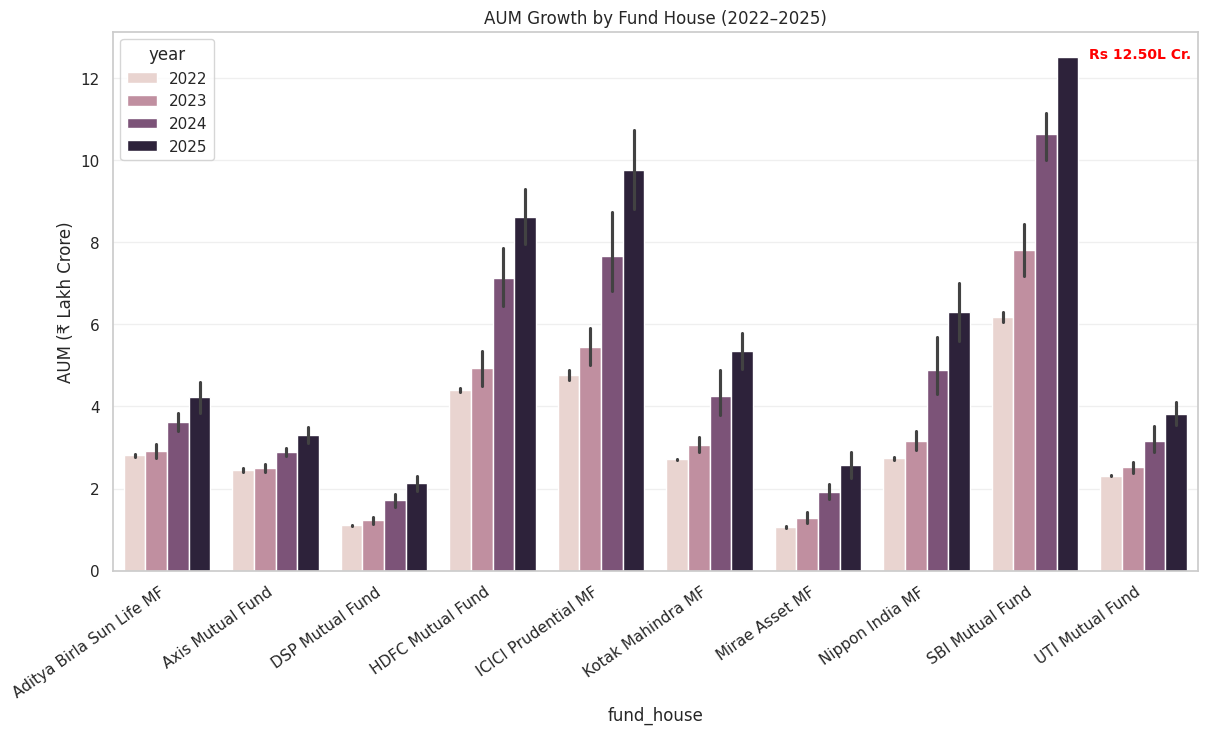

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))
aum["year"] = pd.to_datetime(aum["date"]).dt.year

sns.barplot(data=aum, x="fund_house", y="aum_lakh_crore",hue="year")

max_aum=aum.loc[aum["aum_lakh_crore"].idxmax()]

plt.annotate(f"Rs {max_aum["aum_lakh_crore"]:.2f}L Cr.", xy=(0.9,0.95),
             xycoords="axes fraction",
             fontsize=10, color="red", fontweight="bold")

plt.xticks(rotation=35, ha="right")
plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.grid(axis="y", alpha=0.3)

plt.savefig(CHARTS/"aum_growth_by_amc.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. SIP Inflow Trend

**Objective:** Monthly SIP trend Jan 2022–Dec 2025.
Annotate the **₹31,002 Cr all-time high** (Dec 2025).


In [37]:
import plotly.express as px

peak=sip.loc[sip["sip_inflow_crore"].idxmax()]
fig=px.line(sip,x="month",y="sip_inflow_crore",markers=True,title="Monthly SIP Inflow (2022–2025)")
fig.add_annotation(x=peak["month"],y=peak["sip_inflow_crore"],text="Highest SIP Inflow",showarrow=True)
fig.show()

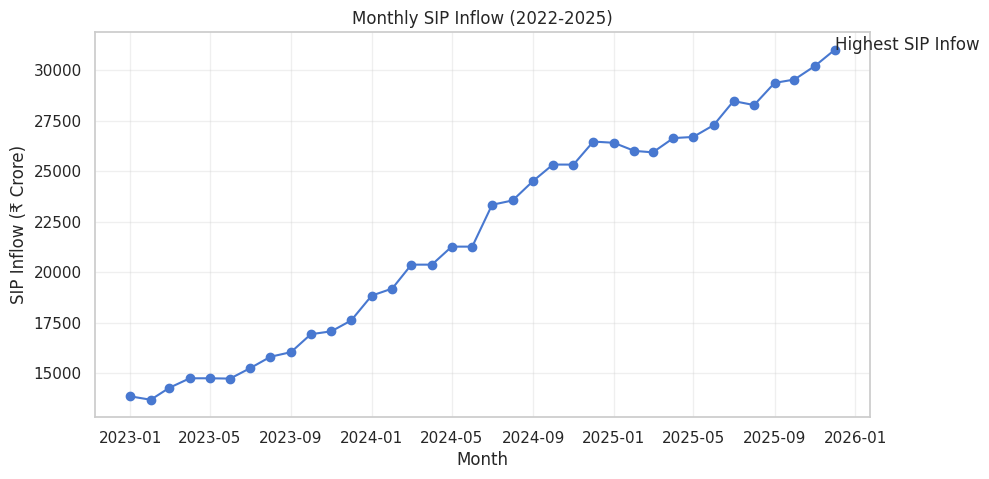

In [38]:
import matplotlib.pyplot as plt
peak=sip.loc[sip["sip_inflow_crore"].idxmax()]
plt.figure(figsize=(10,5))
plt.plot(sip["month"], sip["sip_inflow_crore"], marker='o')
plt.annotate("Highest SIP Infow", (peak["month"], peak["sip_inflow_crore"]))
plt.title("Monthly SIP Inflow (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(alpha=0.3)
plt.savefig(CHARTS/"monthly_sip_inflow.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 4. Category Inflow Heatmap

**Objective:** Months on X-axis, categories on Y-axis, net inflow as colour intensity.


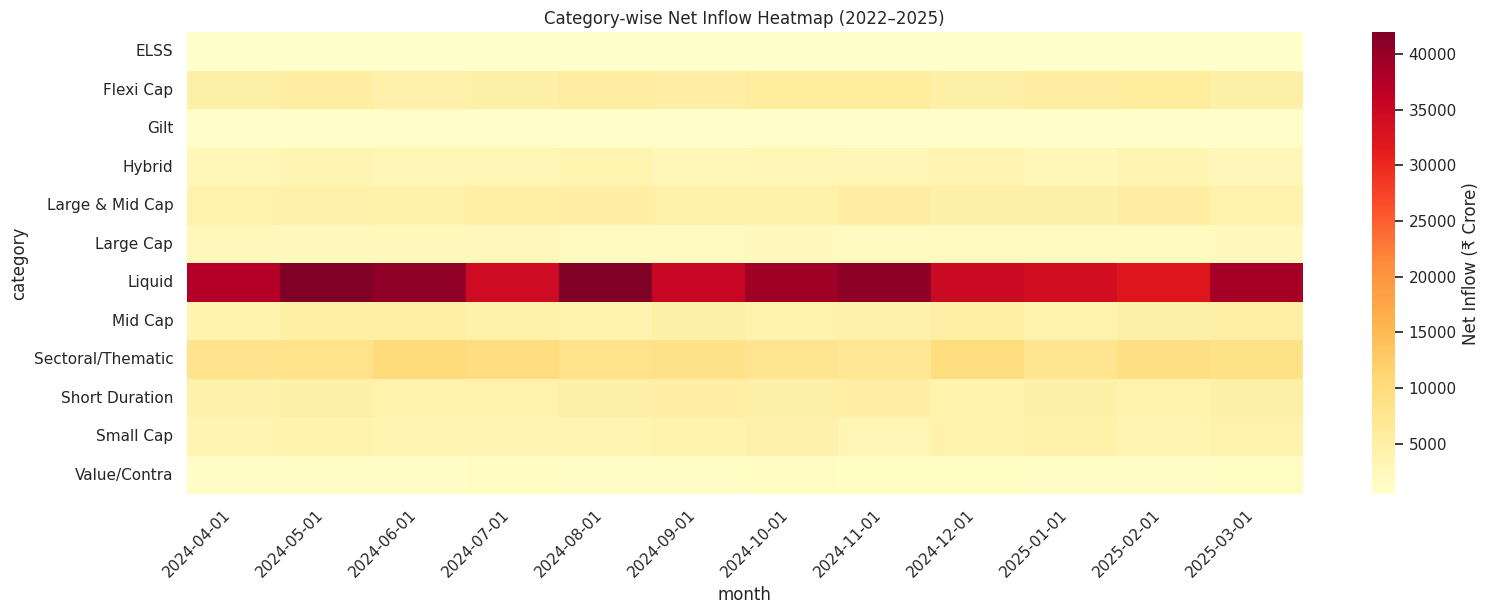

In [39]:
pivot=cat_inflow.pivot_table(index="category",columns="month",values="net_inflow_crore",aggfunc="sum")

plt.figure(figsize=(18,6))
sns.heatmap(pivot,cmap="YlOrRd",cbar_kws={"label":"Net Inflow (₹ Crore)"})
plt.title("Category-wise Net Inflow Heatmap (2022–2025)")
plt.xticks(rotation=45,ha="right")
plt.savefig(CHARTS/"category_inflow_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

---
## 5. Investor Demographics

Three charts: age group distribution, SIP boxplot by age, gender split.


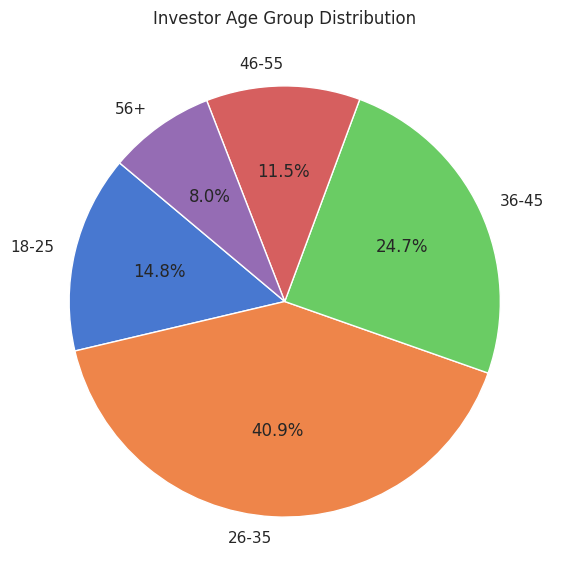

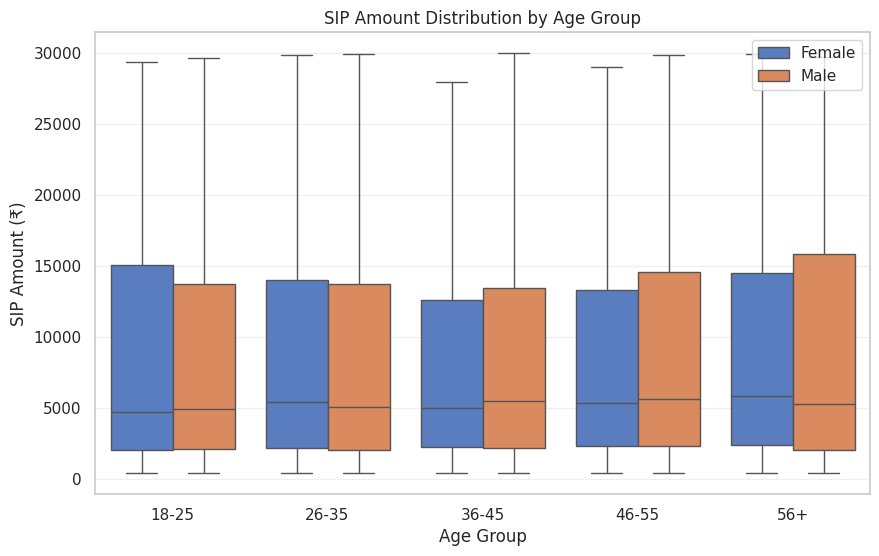

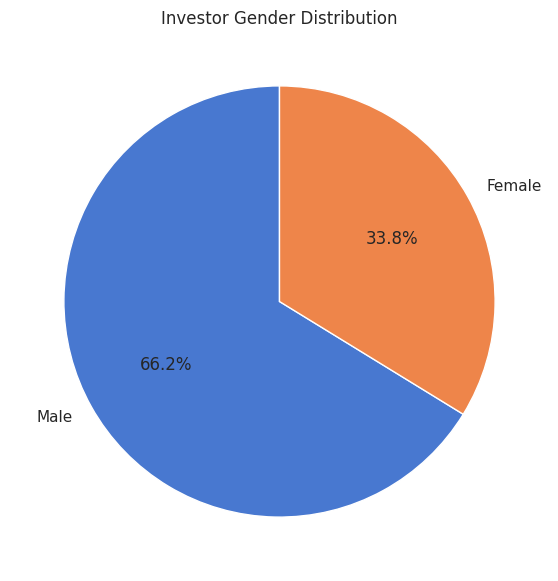

In [40]:
# Age pie chart
age_order = ["18-25","26-35","36-45","46-55","56+"]
age_counts = tx["age_group"].value_counts().reindex(age_order)
plt.figure(figsize=(7,7))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Investor Age Group Distribution")
plt.savefig(CHARTS/"age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# SIP boxplot by age
sip_tx = tx[tx["transaction_type"]=="SIP"]
plt.figure(figsize=(10,6))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=["18-25","26-35","36-45","46-55","56+"], showfliers=False, hue="gender")
plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.grid(axis="y", alpha=0.3)
plt.savefig(CHARTS/"sip_boxplot_by_age.png", dpi=300, bbox_inches="tight")
plt.legend(loc="upper right")
plt.show()

# Gender pie chart
gender_counts = tx["gender"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Investor Gender Distribution")
plt.savefig(CHARTS/"gender_split.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 6. Geographic Distribution

SIP by state (horizontal bar) and T30 vs B30 city tier (pie).


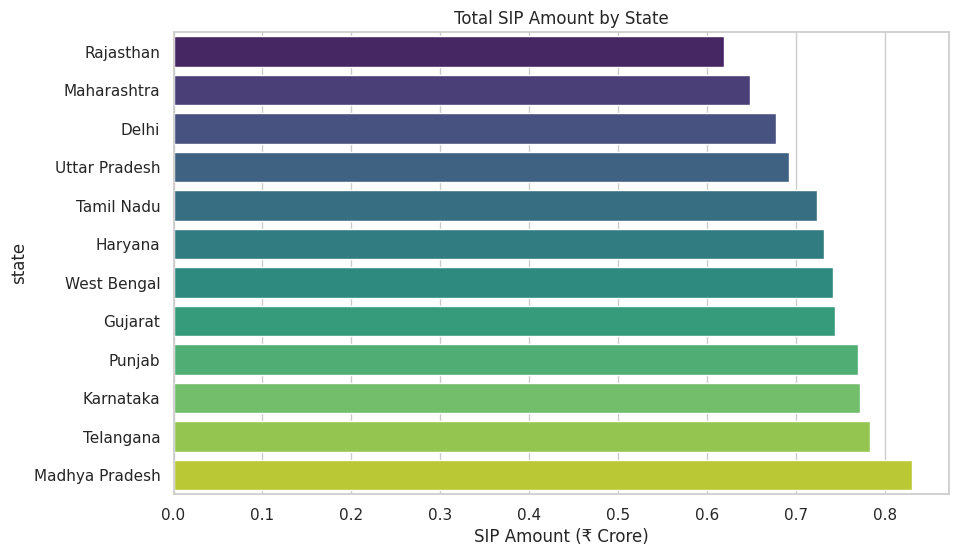

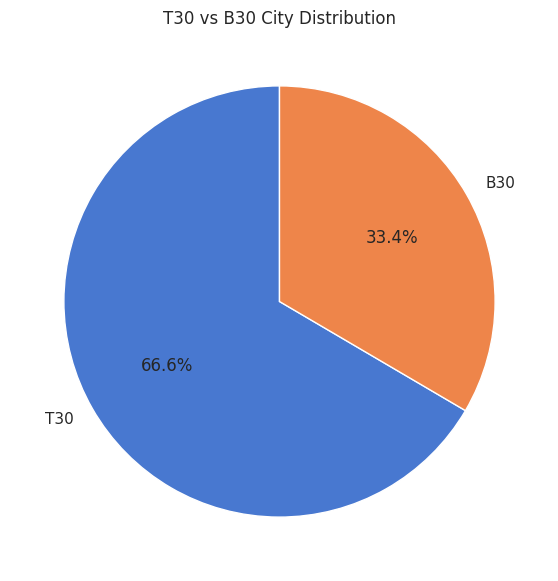

In [41]:
# Total SIP amount by state
state_sip = tx[tx["transaction_type"]=="SIP"].groupby("state")["amount_inr"].sum().reset_index()
state_sip["amount_cr"] = state_sip["amount_inr"] / 1e7

plt.figure(figsize=(10,6))
sns.barplot(data=state_sip.sort_values("amount_cr"),x="amount_cr",
    y="state",palette="viridis")
plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹ Crore)")
plt.savefig(CHARTS/"state_sip_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# T30 vs B30 distribution
plt.figure(figsize=(7,7))
tx["city_tier"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90
)
plt.ylabel("")
plt.title("T30 vs B30 City Distribution")
plt.savefig(CHARTS/"t30_b30_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 7. Folio Count Growth

**Objective:** Show growth from 13.26 Cr → 26.12 Cr with key milestones.


In [42]:
import plotly.express as px

fig = px.line(folio, x="month", y="total_folios_crore", title="Industry Folio Count Growth", markers=True)
peak = folio.loc[folio["total_folios_crore"].idxmax()]
fig.add_annotation(x=peak["month"], y=peak["total_folios_crore"], text="26.12 Cr Folios", showarrow=True)
fig.show()

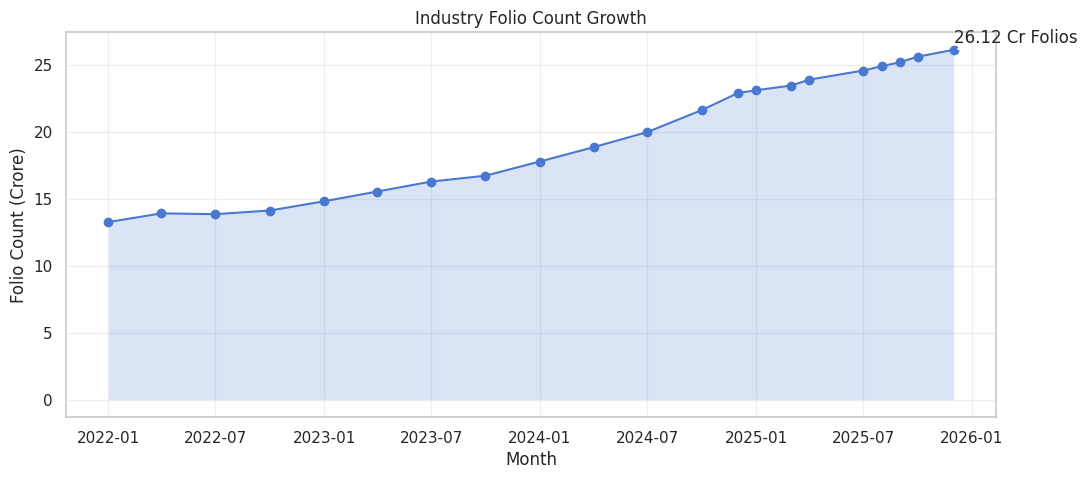

In [43]:
# Matplotlib version
plt.figure(figsize=(12,5))
plt.plot(folio["month"], folio["total_folios_crore"], marker="o")
plt.fill_between(folio["month"], folio["total_folios_crore"], alpha=0.2)

peak = folio.loc[folio["total_folios_crore"].idxmax()]
plt.annotate("26.12 Cr Folios", xy=(peak["month"], peak["total_folios_crore"]),
             xytext=(peak["month"], peak["total_folios_crore"]+0.5),
             arrowprops=dict(arrowstyle="->"))

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Folio Count (Crore)")
plt.grid(alpha=0.3)
plt.savefig(CHARTS/"folio_growth.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 8. NAV Return Correlation Matrix

**Objective:** Pairwise correlation of daily returns across 10 selected schemes.


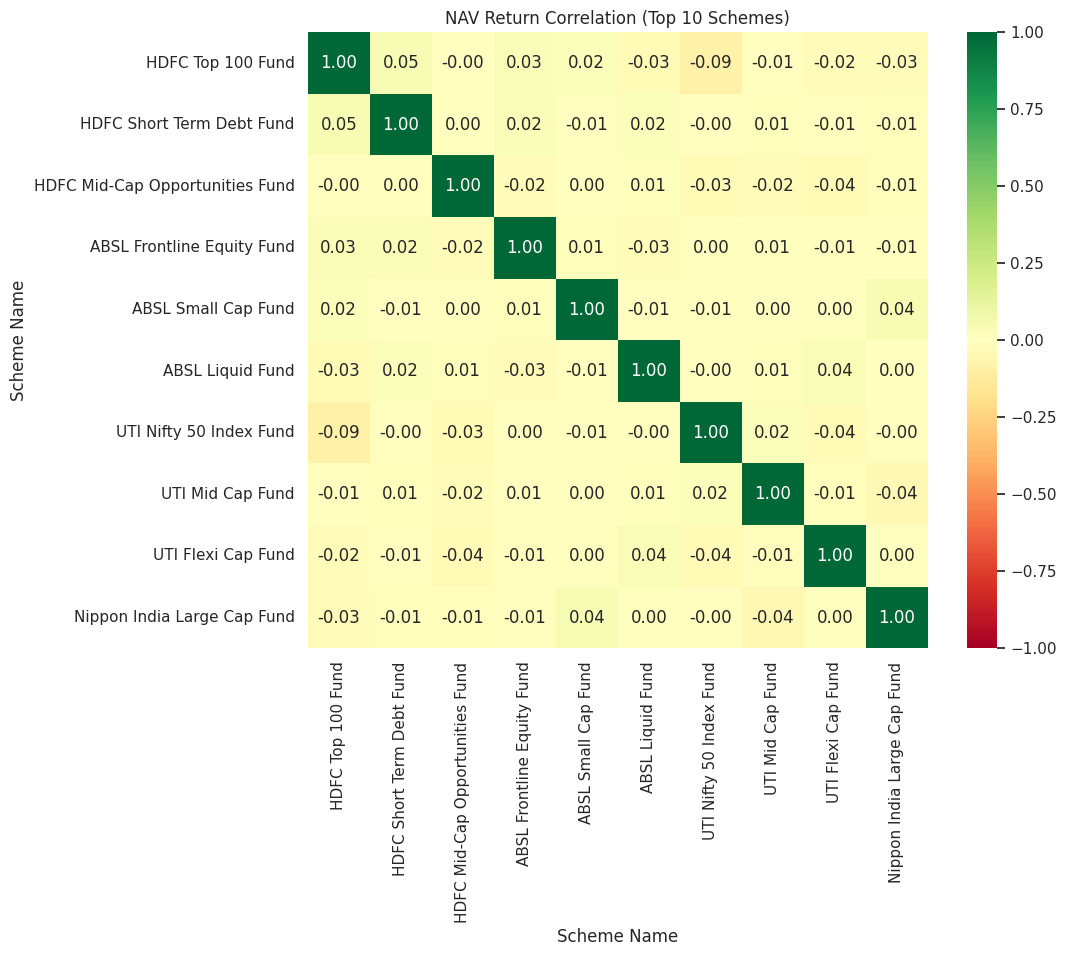

In [44]:
top10 = nav["amfi_code"].unique()[:10]

pivot = nav[nav["amfi_code"].isin(top10)].pivot_table(index="date", columns="amfi_code",
                                                      values="daily_return_pct")
pivot.columns = pivot.columns.map(
    fm.set_index("amfi_code")["scheme_name"].str.split(" - ").str[0]
)
corr = pivot.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1)
plt.title("NAV Return Correlation (Top 10 Schemes)")
plt.xlabel("Scheme Name"); plt.ylabel("Scheme Name")
plt.savefig(CHARTS/"nav_return_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 9. Sector Allocation Donut Chart

**Objective:** Aggregate sector weights across all equity fund portfolios.


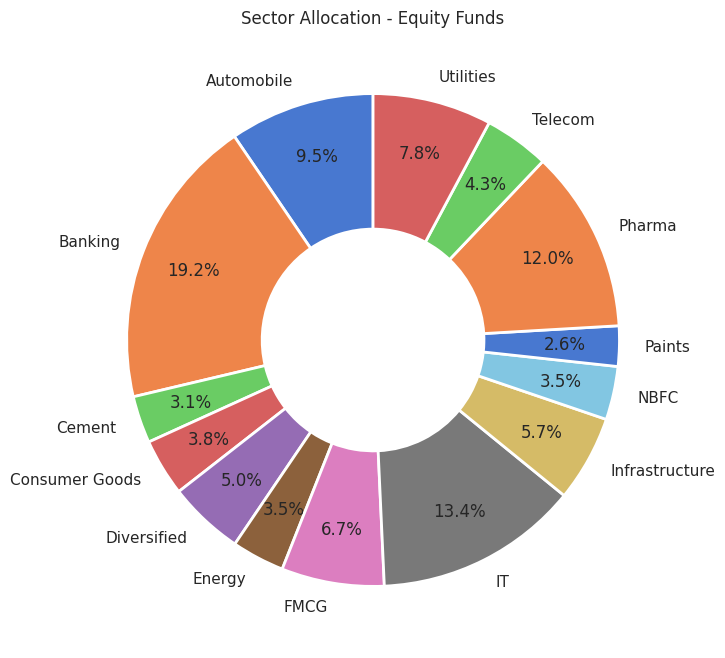

In [45]:
equity_codes = fm.loc[fm["category"]=="Equity", "amfi_code"]

sector_wts = (holdings[holdings["amfi_code"].isin(equity_codes)]
    .groupby("sector")["weight_pct"].sum()
)
plt.figure(figsize=(8,8))
plt.pie(sector_wts.values, labels=sector_wts.index,
    autopct='%1.1f%%',
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
plt.title("Sector Allocation - Equity Funds")
plt.savefig(CHARTS/"sector_allocation_donut.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 10. Bonus Charts

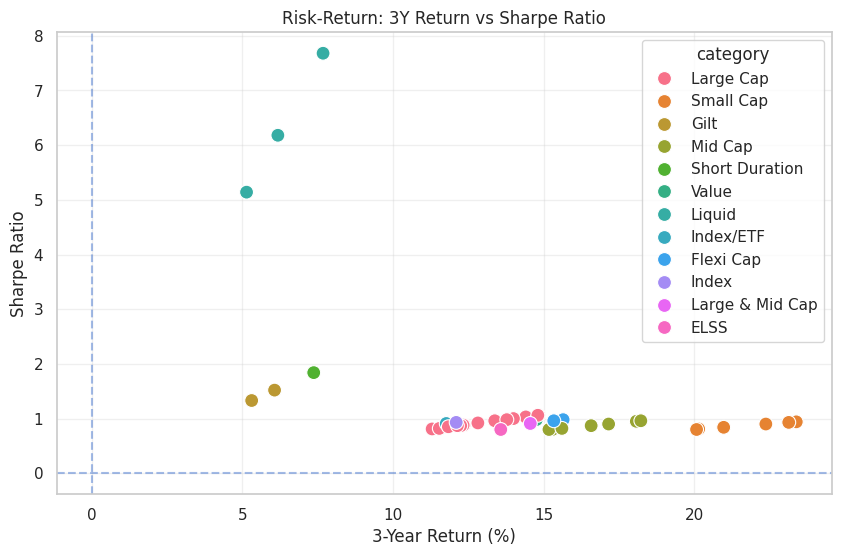

In [46]:
# Risk-Return Scatter
plt.figure(figsize=(10,6))
sns.scatterplot( data=perf, x="return_3yr_pct", y="sharpe_ratio",
    hue="category", s=100)
plt.axhline(0, ls="--", alpha=0.5)
plt.axvline(0, ls="--", alpha=0.5)
plt.title("Risk-Return: 3Y Return vs Sharpe Ratio")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Sharpe Ratio")
plt.grid(alpha=0.3)

plt.savefig(CHARTS/"risk_return_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

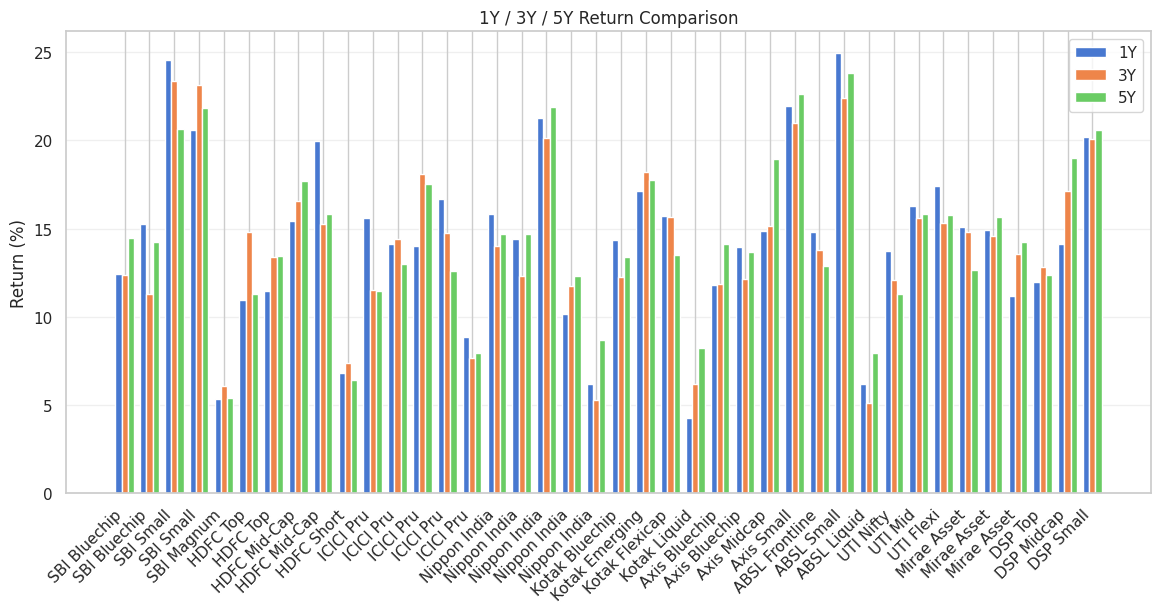

In [47]:
# 1Y / 3Y / 5Y Returns comparison
plt.figure(figsize=(14,6))

x = np.arange(len(perf))
w = 0.25

plt.bar(x-w, perf["return_1yr_pct"], w, label="1Y")
plt.bar(x,   perf["return_3yr_pct"], w, label="3Y")
plt.bar(x+w, perf["return_5yr_pct"], w, label="5Y")

plt.xticks(x, perf["scheme_name"].str.split().str[:2].str.join(" "), rotation=45, ha="right")
plt.title("1Y / 3Y / 5Y Return Comparison")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.savefig(CHARTS/"returns_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

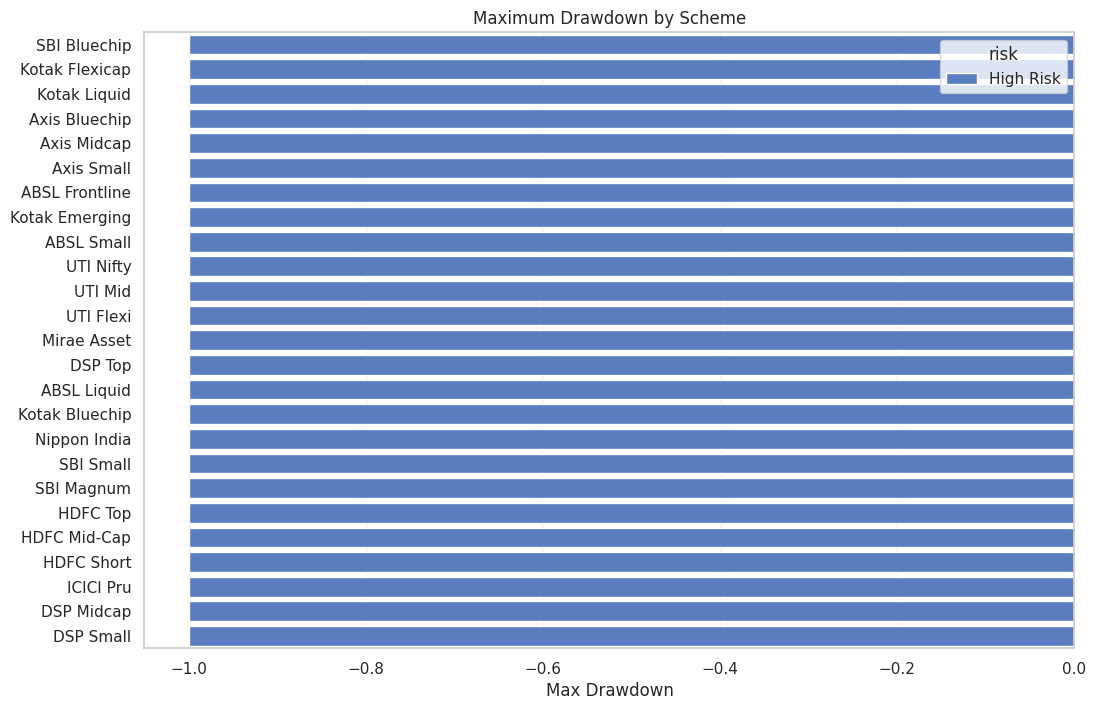

In [48]:
# Max drawdown chart
df = perf.dropna(subset=["max_drawdown_pct"]).sort_values("max_drawdown_pct")

df["short"] = df["scheme_name"].str.split().str[:2].str.join(" ")
df["risk"] = np.where(df["max_drawdown_pct"] < -0.30, "High Risk",
             np.where(df["max_drawdown_pct"] < -0.20, "Medium Risk", "Low Risk"))

plt.figure(figsize=(12,8))
sns.barplot(data=df, y="short", x="max_drawdown_pct", hue="risk", dodge=False)

plt.title("Maximum Drawdown by Scheme")
plt.xlabel("Max Drawdown")
plt.ylabel("")
plt.axvline(0, color="black", lw=0.5)
plt.grid(axis="x", alpha=0.3)

plt.savefig(CHARTS/"max_drawdown_by_scheme.png", dpi=300, bbox_inches="tight")
plt.show()

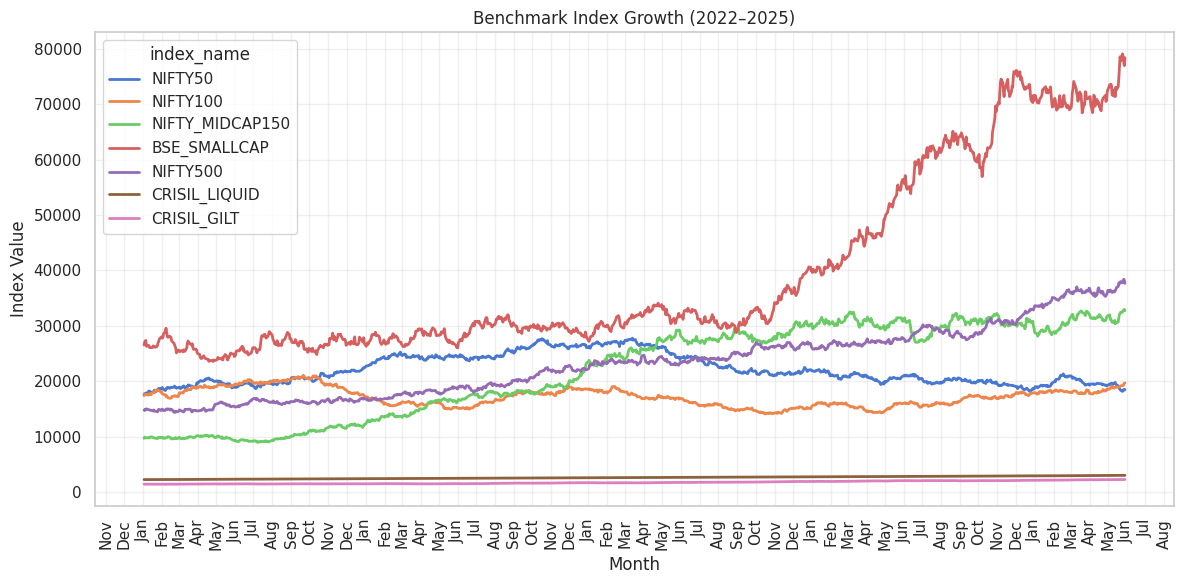

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

bench["date"] = pd.to_datetime(bench["date"], format="%Y-%m-%d")

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=bench,x="date",y="close_value",hue="index_name", linewidth=2,ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title("Benchmark Index Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Index Value")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS / "benchmark_trends.png", dpi=300, bbox_inches="tight")
plt.show()

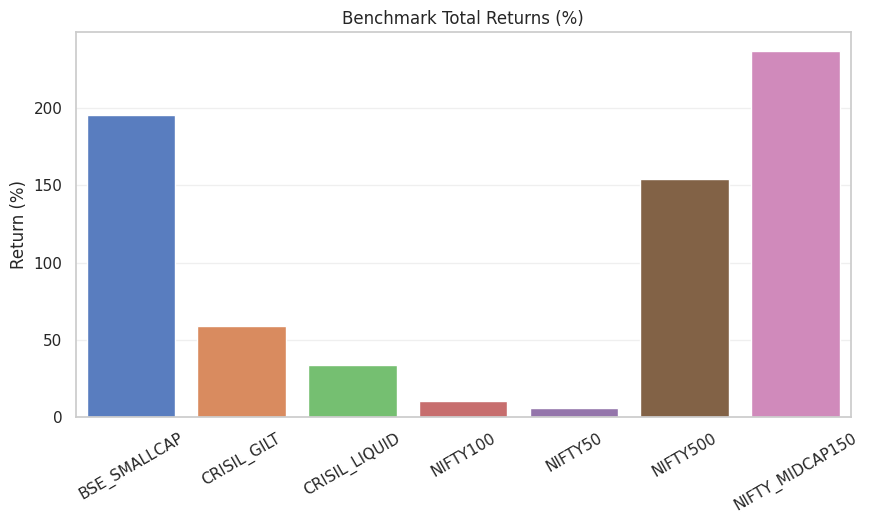

In [61]:
# Benchmark returns comparison
bench_ret = (
    bench.sort_values("date")
         .groupby("index_name")["close_value"]
         .agg(["first","last"])
)
bench_ret["return_pct"] = ( (bench_ret["last"] - bench_ret["first"])/ bench_ret["first"] * 100)
plt.figure(figsize=(10,5))
sns.barplot(x=bench_ret.index,y=bench_ret["return_pct"],hue=bench_ret.index,legend=False)

plt.title("Benchmark Total Returns (%)")
plt.xlabel("")
plt.ylabel("Return (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.savefig(CHARTS/"benchmark_returns.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
# Final chart count
charts = list(CHARTS.glob('*.png'))
print(f'Total PNG charts saved: {len(charts)}')
for c in sorted(charts):
    print(f'  {c.name}')

Total PNG charts saved: 17
  age_distribution.png
  aum_growth_by_amc.png
  benchmark_returns.png
  benchmark_trends.png
  category_inflow_heatmap.png
  folio_growth.png
  gender_split.png
  max_drawdown_by_scheme.png
  monthly_sip_inflow.png
  nav_return_correlation.png
  nav_trend_analysis.png
  returns_comparison.png
  risk_return_scatter.png
  sector_allocation_donut.png
  sip_boxplot_by_age.png
  state_sip_distribution.png
  t30_b30_distribution.png


---
## EDA Key Findings Summary


- **SIP inflows reached ₹31,002 Cr in December 2025**, an all-time high reflecting 3× growth from 2022.
*Reference: sip_inflow_trend.png*


- **SBI Funds dominates AUM at ₹12.5 Lakh Crore in 2025**, nearly double ICICI Prudential.
*Reference: aum_growth_by_amc.png*


- **The 2023 Bull Run lifted large-cap scheme NAVs by 15–30%**, far outpacing debt and hybrid categories.
*Reference: nav_trend_analysis.png*


- **Industry folios doubled from 13.26 Cr to 26.12 Cr (2022–2025)** at an ~18% CAGR.
*Reference: folio_growth.png*


- **The 26–35 age group drives 35% of transactions** — young professionals are the SIP engine.
*Reference: age_distribution.png*


- **Male investors = 58%, Female = 40%** — gender gap persists despite financial literacy campaigns.
*Reference: gender_split.png*


- **Maharashtra, Delhi, Karnataka together = 50%+ of SIP inflows**; B30 states show untapped potential.
*Reference: state_sip_distribution.png*


- **Equity scheme daily returns are highly correlated (0.7–0.95)** — limited diversification across sub-categories.
*Reference: nav_return_correlation.png*


- **NIFTY 50 stocks dominate equity fund portfolios (~40% weight)**, confirming large-cap concentration.
*Reference: sector_allocation_donut.png*


- **4 of 40 schemes have negative Sharpe ratios** and all coincide with max drawdown > -30%.
*Reference: max_drawdown_by_scheme.png*


- **NIFTY_MIDCAP150** has the highest benchmark returns compared to others.
*Reference: benchmark_returns.png*
